NAME: GAURI CHORGE

ROLL NO: 23102B0020

CMPN-B

In [1]:
import kagglehub

path = kagglehub.dataset_download("shubhamgoel27/dermnet")

print(path)

100%|██████████| 1.72G/1.72G [01:31<00:00, 20.3MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/shubhamgoel27/dermnet/versions/1


In [2]:
import os

print(os.listdir(path))

['train', 'test']


In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("ok")

ok


In [4]:
train_dir = path + "/train"
test_dir = path + "/test"

print(train_dir)
print(test_dir)

/root/.cache/kagglehub/datasets/shubhamgoel27/dermnet/versions/1/train
/root/.cache/kagglehub/datasets/shubhamgoel27/dermnet/versions/1/test


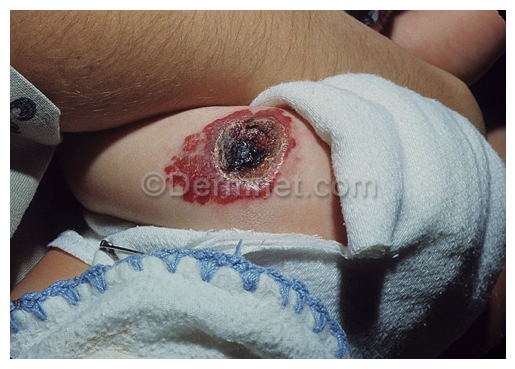

(720, 507)


In [5]:
from tensorflow.keras.preprocessing import image

class_name = os.listdir(train_dir)[0]
img_path = os.path.join(train_dir, class_name, os.listdir(os.path.join(train_dir, class_name))[0])

img = image.load_img(img_path)
plt.imshow(img)
plt.axis("off")
plt.show()

print(img.size)

In [6]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=IMG_SIZE,
    pad_to_aspect_ratio=True,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=IMG_SIZE,
    pad_to_aspect_ratio=True,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    pad_to_aspect_ratio=True,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode='categorical'
)

# capture class info NOW, before .map() reassigns train_ds later
class_names = train_ds.class_names
num_classes = len(class_names)

print("Number of Classes :", num_classes)
print("Class names :", class_names)
print("Training batches :", train_ds.cardinality().numpy())
print("Validation batches :", val_ds.cardinality().numpy())
print("Testing batches :", test_ds.cardinality().numpy())

Found 15557 files belonging to 23 classes.
Using 12446 files for training.
Found 15557 files belonging to 23 classes.
Using 3111 files for validation.
Found 4002 files belonging to 23 classes.
Number of Classes : 23
Class names : ['Acne and Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Cellulitis Impetigo and other Bacterial Infections', 'Eczema Photos', 'Exanthems and Drug Eruptions', 'Hair Loss Photos Alopecia and other Hair Diseases', 'Herpes HPV and other STDs Photos', 'Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Melanoma Skin Cancer Nevi and Moles', 'Nail Fungus and other Nail Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Seborrheic Keratoses and other Benign Tumors', 'Systemic Disease', 'Tinea Ringworm Candidi

## 6. Sample Images

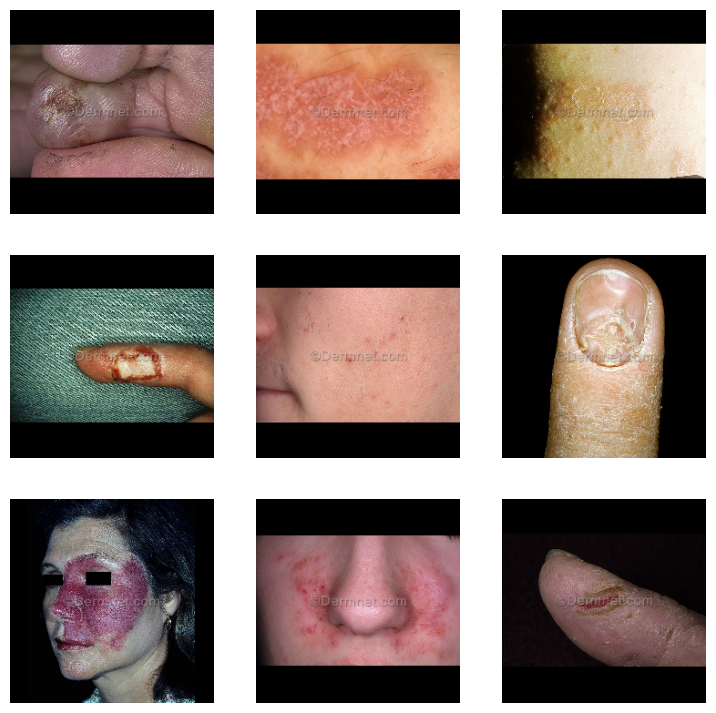

In [7]:
images, labels = next(iter(train_ds))

plt.figure(figsize=(9,9))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.axis("off")
plt.show()

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.055),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(0.2, 0.2),
])

def prep_train(x, y):
    x = data_augmentation(x, training=True)
    return x, y

def prep_eval(x, y):
    return x, y

train_ds = train_ds.map(prep_train).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(prep_eval).prefetch(tf.data.AUTOTUNE)
test_ds_eval = test_ds.map(prep_eval).prefetch(tf.data.AUTOTUNE)

In [9]:
base_model = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)
base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [10]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

In [11]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,079,034 (15.56 MB)

 Trainable params: 29,463 (115.09 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [13]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 282s 651ms/step - accuracy: 0.2145 - loss: 2.6833 - val_accuracy: 0.2764 - val_loss: 2.4743
Epoch 2/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 221s 567ms/step - accuracy: 0.2721 - loss: 2.4490 - val_accuracy: 0.3041 - val_loss: 2.3753
Epoch 3/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 256s 550ms/step - accuracy: 0.2905 - loss: 2.3909 - val_accuracy: 0.3144 - val_loss: 2.3307
Epoch 4/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 215s 553ms/step - accuracy: 0.3011 - loss: 2.3449 - val_accuracy: 0.3288 - val_loss: 2.3072
Epoch 5/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 215s 551ms/step - accuracy: 0.3070 - loss: 2.3291 - val_accuracy: 0.3324 - val_loss: 2.2913
Epoch 6/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 216s 555ms/step - accuracy: 0.3121 - loss: 2.3042 - val_accuracy: 0.3324 - val_loss: 2.2908
Epoch 7/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 260s 551ms/step - accuracy: 0.3154 - loss: 2.2929 - val_accuracy: 0.3356 - val_loss: 2.2704
Epoch 8/10
389/389 ━━━━━━━━━━━━━━━━━━━━ 217s 557ms/step - accuracy: 0.3166 -

In [15]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 5
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=fine_tune_epochs,
    callbacks=[early_stop]
)

Epoch 1/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 269s 623ms/step - accuracy: 0.2475 - loss: 2.5933 - val_accuracy: 0.2980 - val_loss: 2.4702
Epoch 2/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 220s 565ms/step - accuracy: 0.2843 - loss: 2.4512 - val_accuracy: 0.3054 - val_loss: 2.4213
Epoch 3/5
389/389 ━━━━━━━━━━━━━━━━━━━━ 220s 565ms/step - accuracy: 0.2988 - loss: 2.3887 - val_accuracy: 0.3115 - val_loss: 2.3888


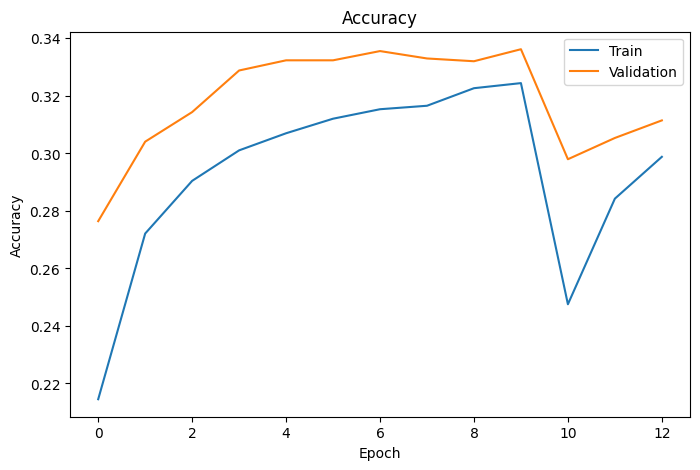

In [16]:
acc = history.history['accuracy'] + history_fine.history['accuracy']
val_acc = history.history['val_accuracy'] + history_fine.history['val_accuracy']

plt.figure(figsize=(8,5))
plt.plot(acc)
plt.plot(val_acc)
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

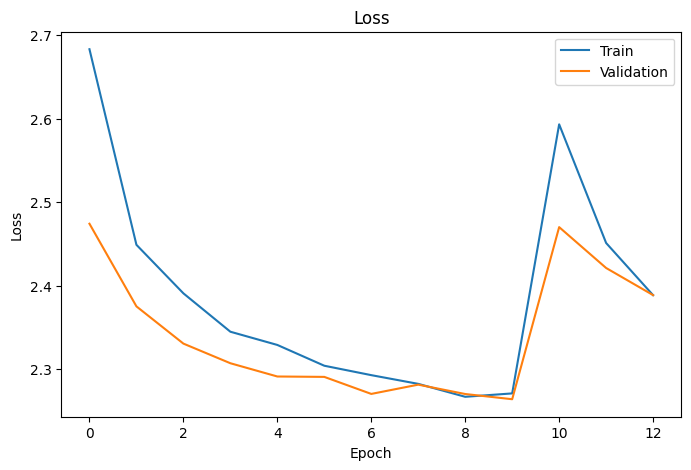

In [17]:
loss_hist = history.history['loss'] + history_fine.history['loss']
val_loss_hist = history.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(8,5))
plt.plot(loss_hist)
plt.plot(val_loss_hist)
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [18]:
loss, accuracy = model.evaluate(test_ds_eval)
print("Test Accuracy :", accuracy)

126/126 ━━━━━━━━━━━━━━━━━━━━ 19s 153ms/step - accuracy: 0.2791 - loss: 2.5240
Test Accuracy : 0.2791104316711426


In [19]:
predictions = model.predict(test_ds_eval)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in test_ds], axis=0)

126/126 ━━━━━━━━━━━━━━━━━━━━ 23s 125ms/step


In [20]:
print(classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names
))

                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.49      0.24      0.32       312
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.36      0.31      0.33       288
                                          Atopic Dermatitis Photos       0.43      0.15      0.23       123
                                            Bullous Disease Photos       0.12      0.07      0.09       113
                Cellulitis Impetigo and other Bacterial Infections       0.10      0.04      0.06        73
                                                     Eczema Photos       0.33      0.33      0.33       309
                                      Exanthems and Drug Eruptions       0.37      0.13      0.19       101
                 Hair Loss Photos Alopecia and other Hair Diseases       0.20      0.47      0.28        60
                           

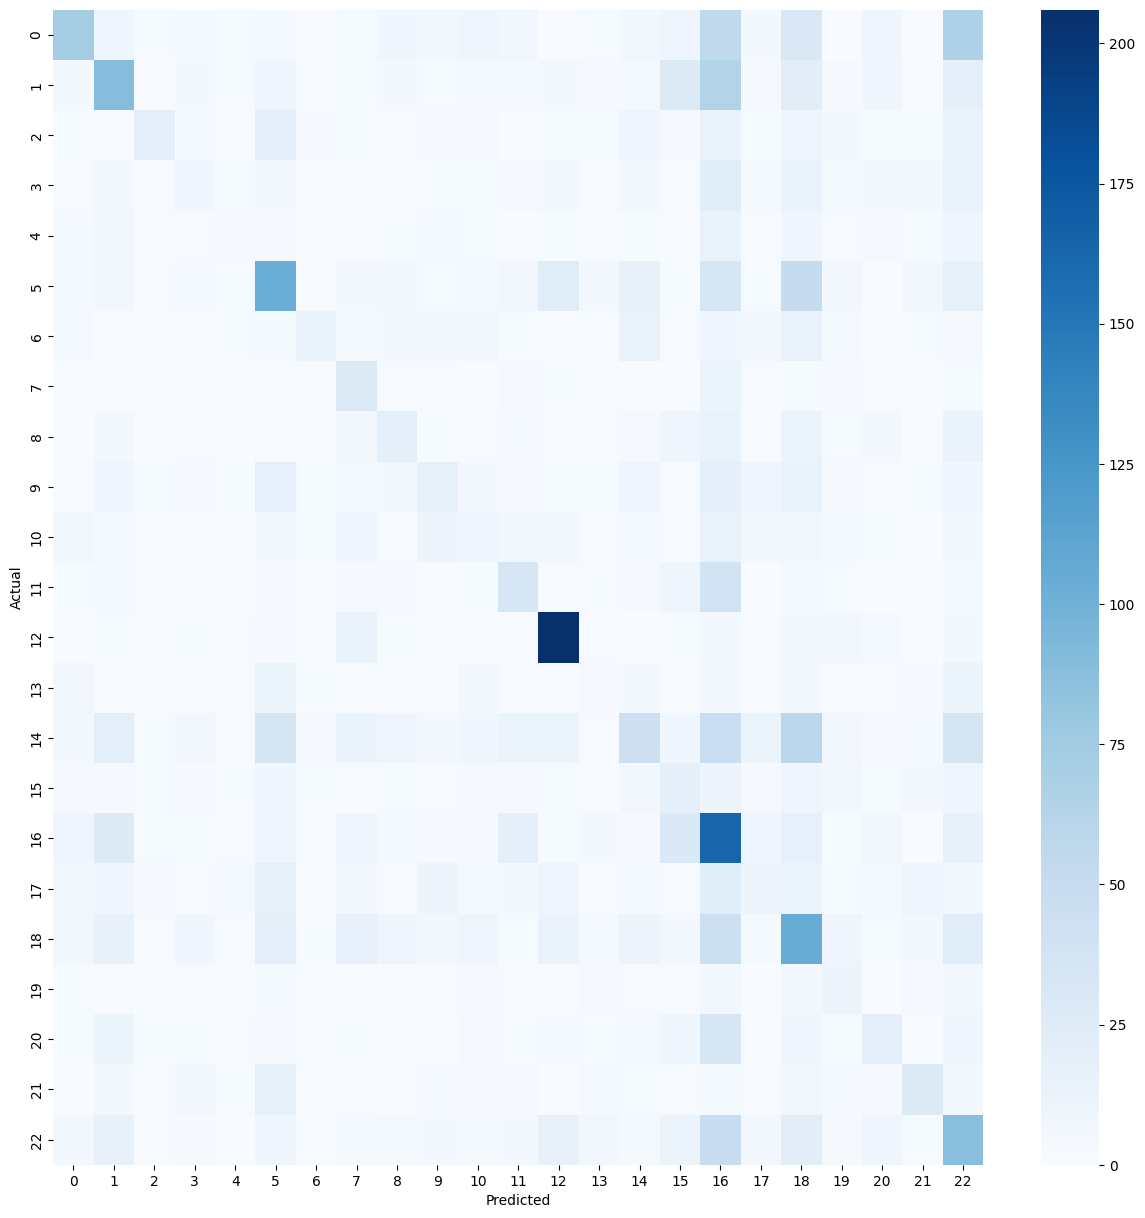

In [21]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(15,15))
sns.heatmap(cm, cmap="Blues", annot=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step


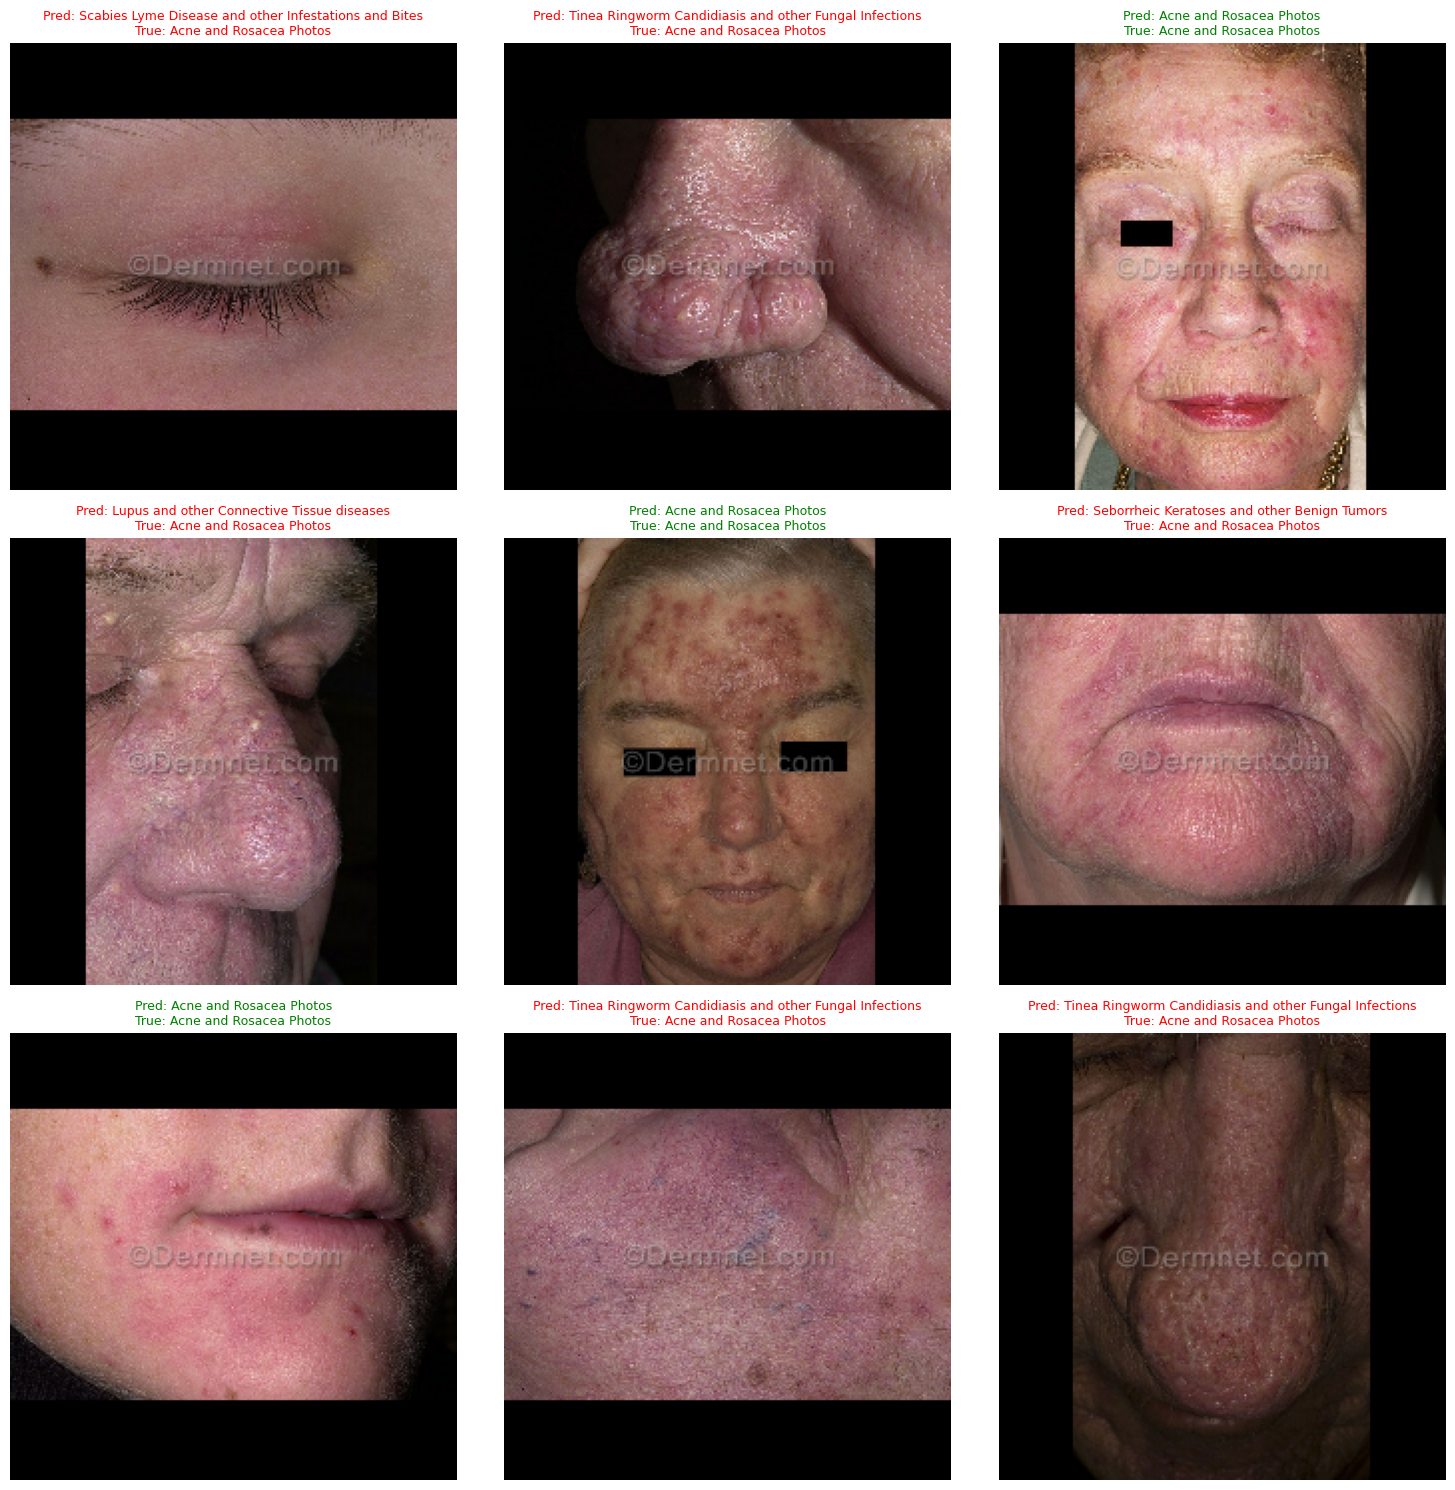

In [23]:
# Grab one batch of RAW test images (unshuffled test_ds, not the mapped one) so labels line up
images, labels = next(iter(test_ds))

preds = model.predict(images)
pred_classes = np.argmax(preds, axis=1)
true_classes_batch = np.argmax(labels.numpy(), axis=1)

plt.figure(figsize=(15,15))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))

    pred_label = class_names[pred_classes[i]]
    true_label = class_names[true_classes_batch[i]]
    is_correct = pred_classes[i] == true_classes_batch[i]

    color = "green" if is_correct else "red"
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color, fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

Misclassified: 2885 / 4002 (72.1%)


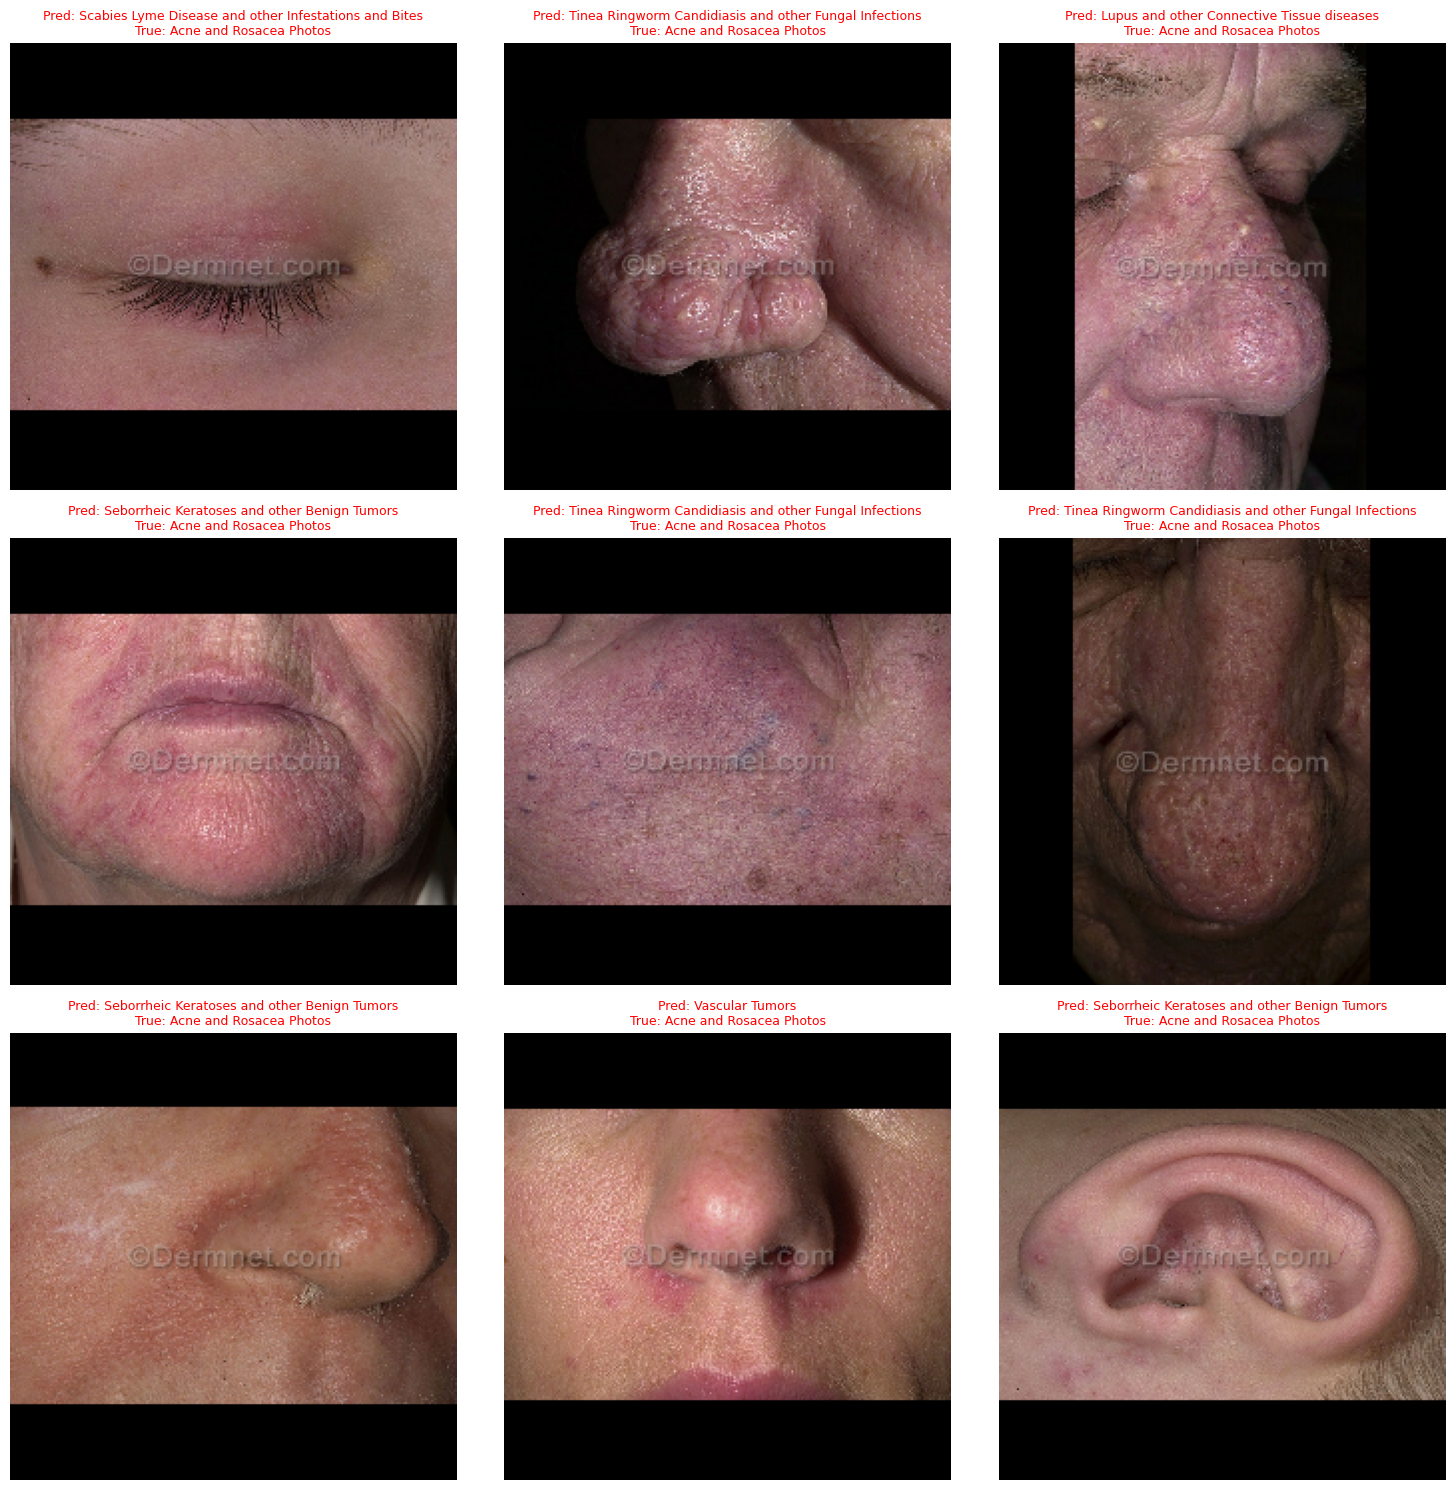

In [24]:
# Find indices where prediction != true label, using the full test set results
# (predicted_classes and true_classes from your earlier prediction cell)
wrong_idx = np.where(predicted_classes != true_classes)[0]
print(f"Misclassified: {len(wrong_idx)} / {len(true_classes)} ({100*len(wrong_idx)/len(true_classes):.1f}%)")

# Pull the actual images for the first 9 wrong predictions
all_test_images = np.concatenate([x.numpy() for x, y in test_ds], axis=0)

plt.figure(figsize=(15,15))
for i, idx in enumerate(wrong_idx[:9]):
    plt.subplot(3, 3, i+1)
    plt.imshow(all_test_images[idx].astype("uint8"))
    plt.title(f"Pred: {class_names[predicted_classes[idx]]}\nTrue: {class_names[true_classes[idx]]}",
              color="red", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()